# Maritime Search & Rescue Object Detection using YOLO28s

This notebook presents the baseline training pipeline for **SentinelBlue**, a UAV-centric maritime Search and Rescue perception system designed with a strong emphasis on realistic deployment constraints. SentinelBlue prioritizes high-quality dataset engineering, controlled augmentation, and reproducible experimentation over architectural novelty, ensuring that the resulting models reflect practical SAR perception requirements rather than purely benchmark-driven optimization.

The dataset integrates SeaDronesSee with carefully selected complementary sources and applies targeted augmentation exclusively within the training split to address minority class scarcity while preserving validation and test integrity. The final taxonomy includes person, boat, jetski, buoy, and emergency_appliance, reflecting operational SAR targets.

This notebook establishes the YOLO28s baseline, providing a balanced starting point for future SentinelBlue experiments involving resolution scaling, edge optimization, and deployment-aware evaluation.

## Environment Setup

This section prepares the training environment by installing the Ultralytics framework and configuring the runtime for controlled experimentation within Kaggle. Ensuring a clean and reproducible environment is particularly important for SentinelBlue because the project emphasizes methodological clarity and experiment traceability across iterations.

External experiment tracking is disabled to prevent unintended logging overhead and to keep all artifacts contained within the notebook workspace. After installation, a lightweight verification step confirms that the Ultralytics package is correctly initialized and that the runtime can access GPU acceleration. Establishing this baseline environment reduces the risk of hidden configuration issues that could affect training stability or reproducibility in later experiments.

In [1]:
# Install Ultralytics
!pip install -q ultralytics

# Disable external logging for reproducibility
import os
os.environ["WANDB_DISABLED"] = "true"

# Verify installation and environment
import ultralytics
ultralytics.checks()

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6841.9/8062.4 GB disk)


## Dataset Configuration

SentinelBlue follows the standard YOLO directory structure, where images and labels are separated by split and linked through a central YAML configuration file. Because the dataset has already undergone a full engineering cycle including balancing, augmentation, and integrity validation, this notebook does not perform many dataset modifications and treats the data as more or less frozen.

The YAML file defines class mappings and split paths, allowing the training pipeline to remain concise while ensuring consistency across experiments. Maintaining a stable dataset reference is essential for SentinelBlue, as it enables reliable comparison between training iterations and supports reproducible research reporting. The configuration paths below are used directly during training and later during full test-set inference.

## Model Training - YOLO28s

This section trains the SentinelBlue baseline using YOLO28s with an explicit training configuration that mirrors the structured experimentation approach adopted throughout the project. Rather than relying on default parameters, key optimization and augmentation settings are specified directly to ensure reproducibility and clear experimental traceability across iterations.

The configuration preserves conservative geometric augmentation because SentinelBlue already incorporates extensive dataset-level augmentation. Photometric variation and moderate scale transformations are retained to maintain robustness to real maritime imaging conditions. The training run is organized under a dedicated project directory, enabling systematic tracking of metrics, checkpoints, and qualitative outputs. 

In [2]:
!nvidia-smi

Sat Mar 21 20:51:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!yolo task=detect mode=train \
model=yolo26s.pt \
data=/kaggle/input/datasets/rupankarmajumdar/sentinelblue/data.yaml \
epochs=30 \
patience=20 \
imgsz=640 \
batch=80 \
lr0=0.007 \
device=0,1 \
workers=12 \
project=training_iteration_1 \
name=training_iteration_1 \
save=True \
save_period=5 \
hsv_h=0.015 \
hsv_s=0.7 \
hsv_v=0.4 \
degrees=0 \
translate=0.1 \
scale=0.4 \
shear=0.0 \
perspective=0.0 \
flipud=0 \
fliplr=0.5 \
mosaic=1.0 \
mixup=0.05 \
copy_paste=0.01 \
amp=True

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=80, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.01, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/rupankarmajumdar/sentinelblue/data.yaml, degrees=0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.007, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=

## Training Metrics Inspection

After training completes, the first step is to examine the recorded learning curves to verify that optimization progressed in a stable and meaningful manner. Ultralytics automatically logs losses and evaluation metrics across epochs, allowing detailed inspection of convergence behaviour without additional instrumentation. For SentinelBlue, these curves are particularly important because the dataset underwent extensive engineering and controlled augmentation prior to training.

Observing bounding box loss stabilization indicates localization learning, while classification and distribution losses reflect how well the model separates SAR classes with varying frequency. The evolution of mAP metrics provides a concise summary of detection quality over time. Consistent downward loss trends combined with steady mAP improvement suggest that the dataset design and training configuration are functioning as intended.

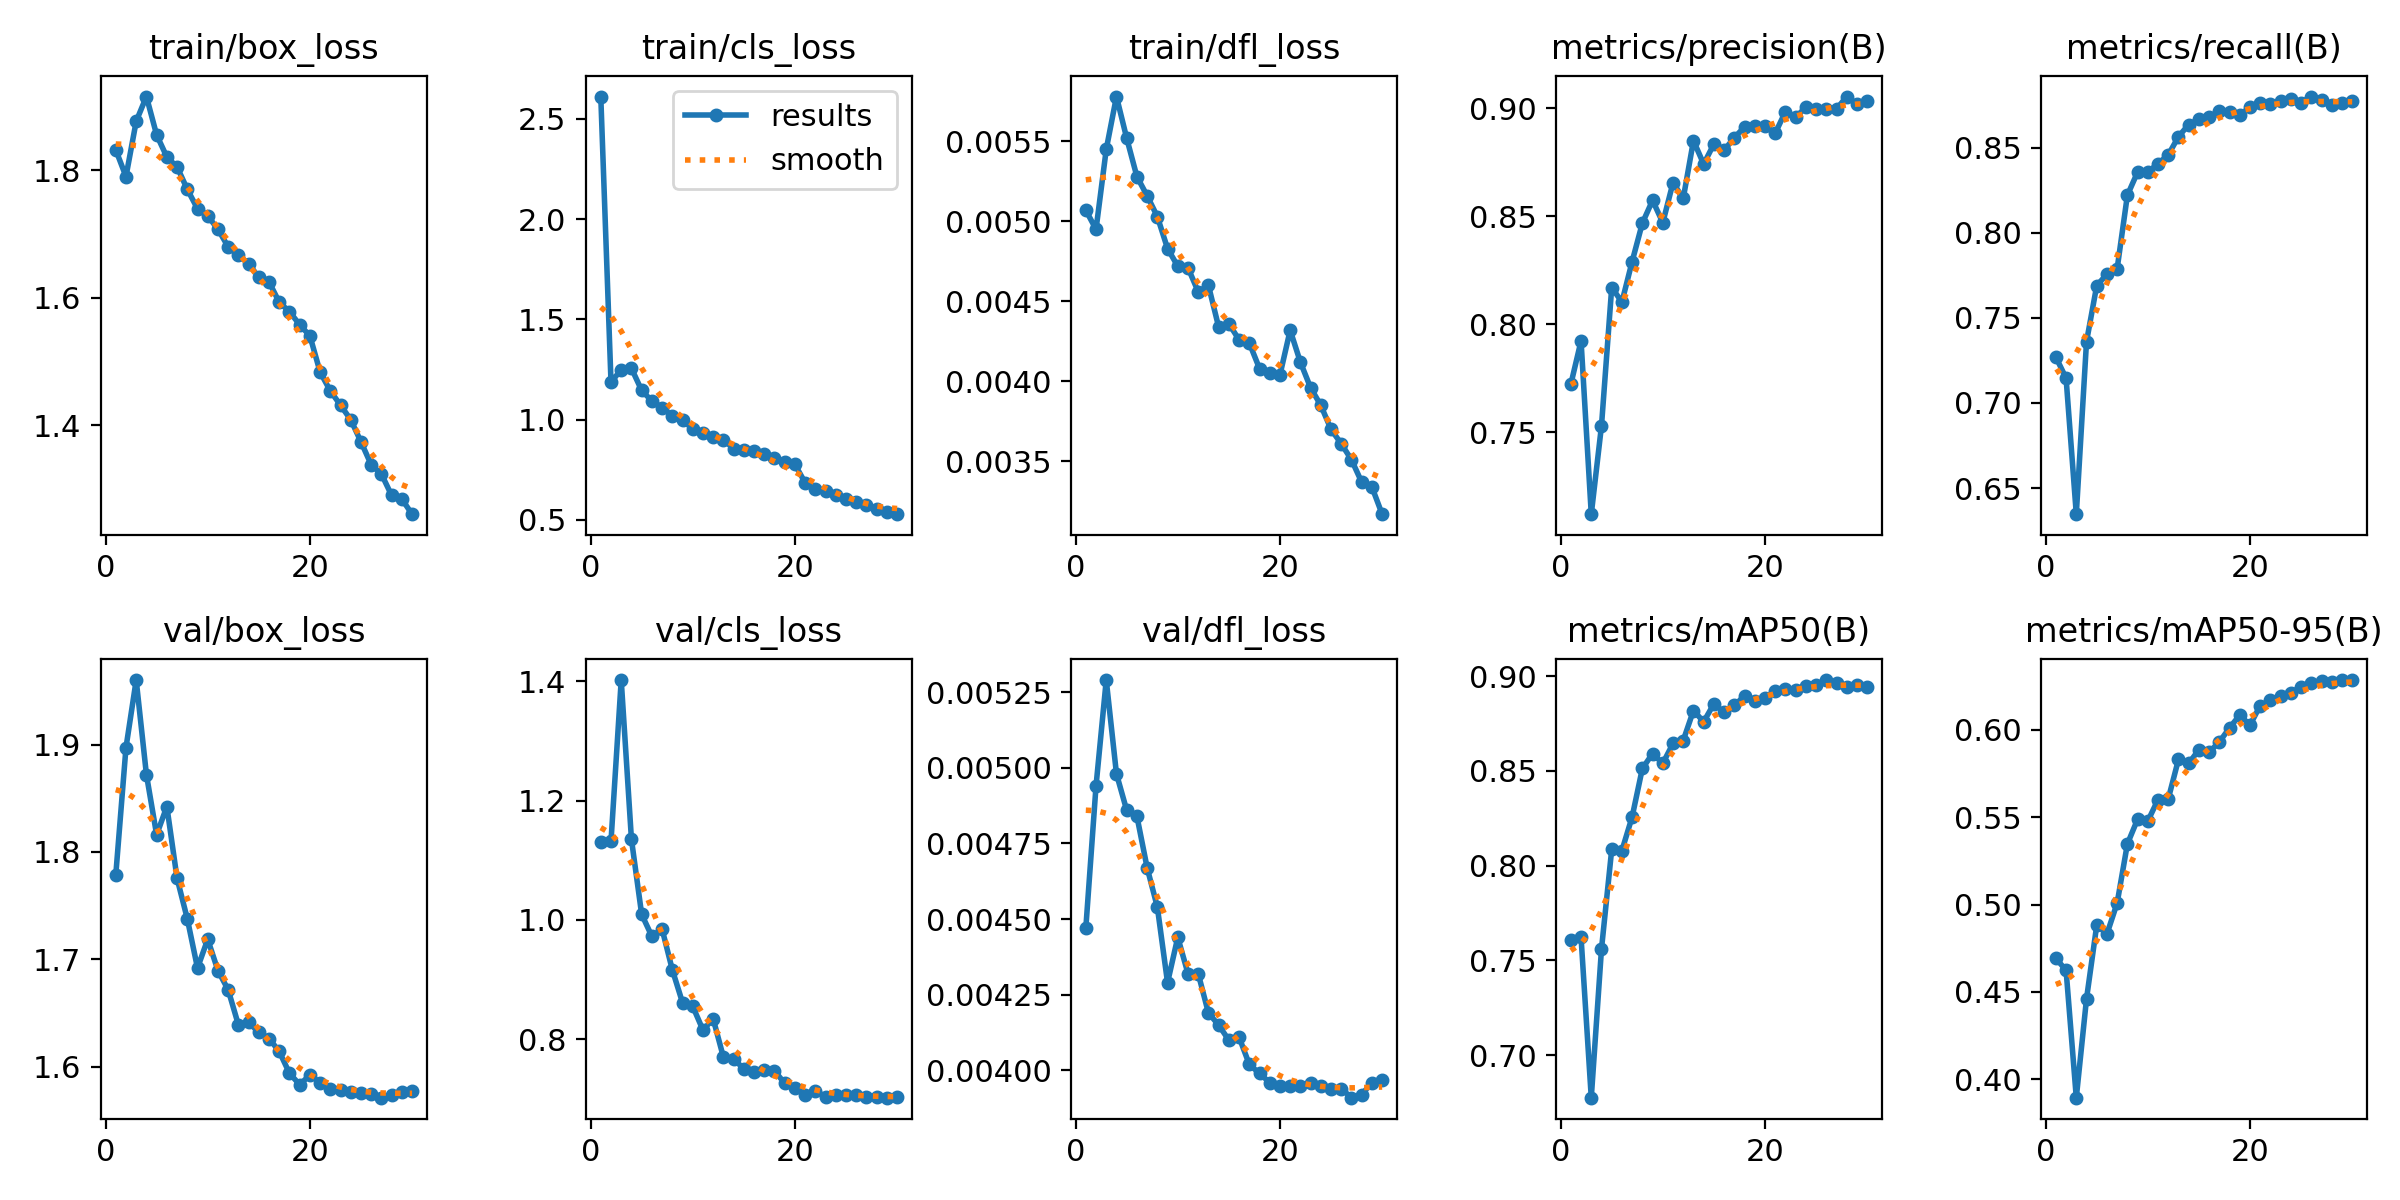

In [4]:
from IPython.display import Image, display
from pathlib import Path

Image("/kaggle/working/runs/detect/training_iteration_1/training_iteration_1/results.png")

## Evaluation Overview

Evaluation on the validation split provides an unbiased estimate of how well the model generalizes beyond the training distribution. Because SentinelBlue strictly avoided validation contamination during augmentation and dataset balancing, the resulting metrics serve as a reliable indicator of real-world SAR detection capability. This separation is critical when the model is intended for operational reasoning tasks such as locating persons in maritime distress.

Diagnostic plots produced by Ultralytics help interpret performance beyond aggregate scores. The confusion matrix highlights class separation behaviour, revealing whether visually similar categories such as boats and jetskis introduce misclassification patterns. Precision–recall and F1 curves further contextualize the trade-off between detection sensitivity and false positives, which is especially important in SAR scenarios where missed detections may carry higher operational risk.

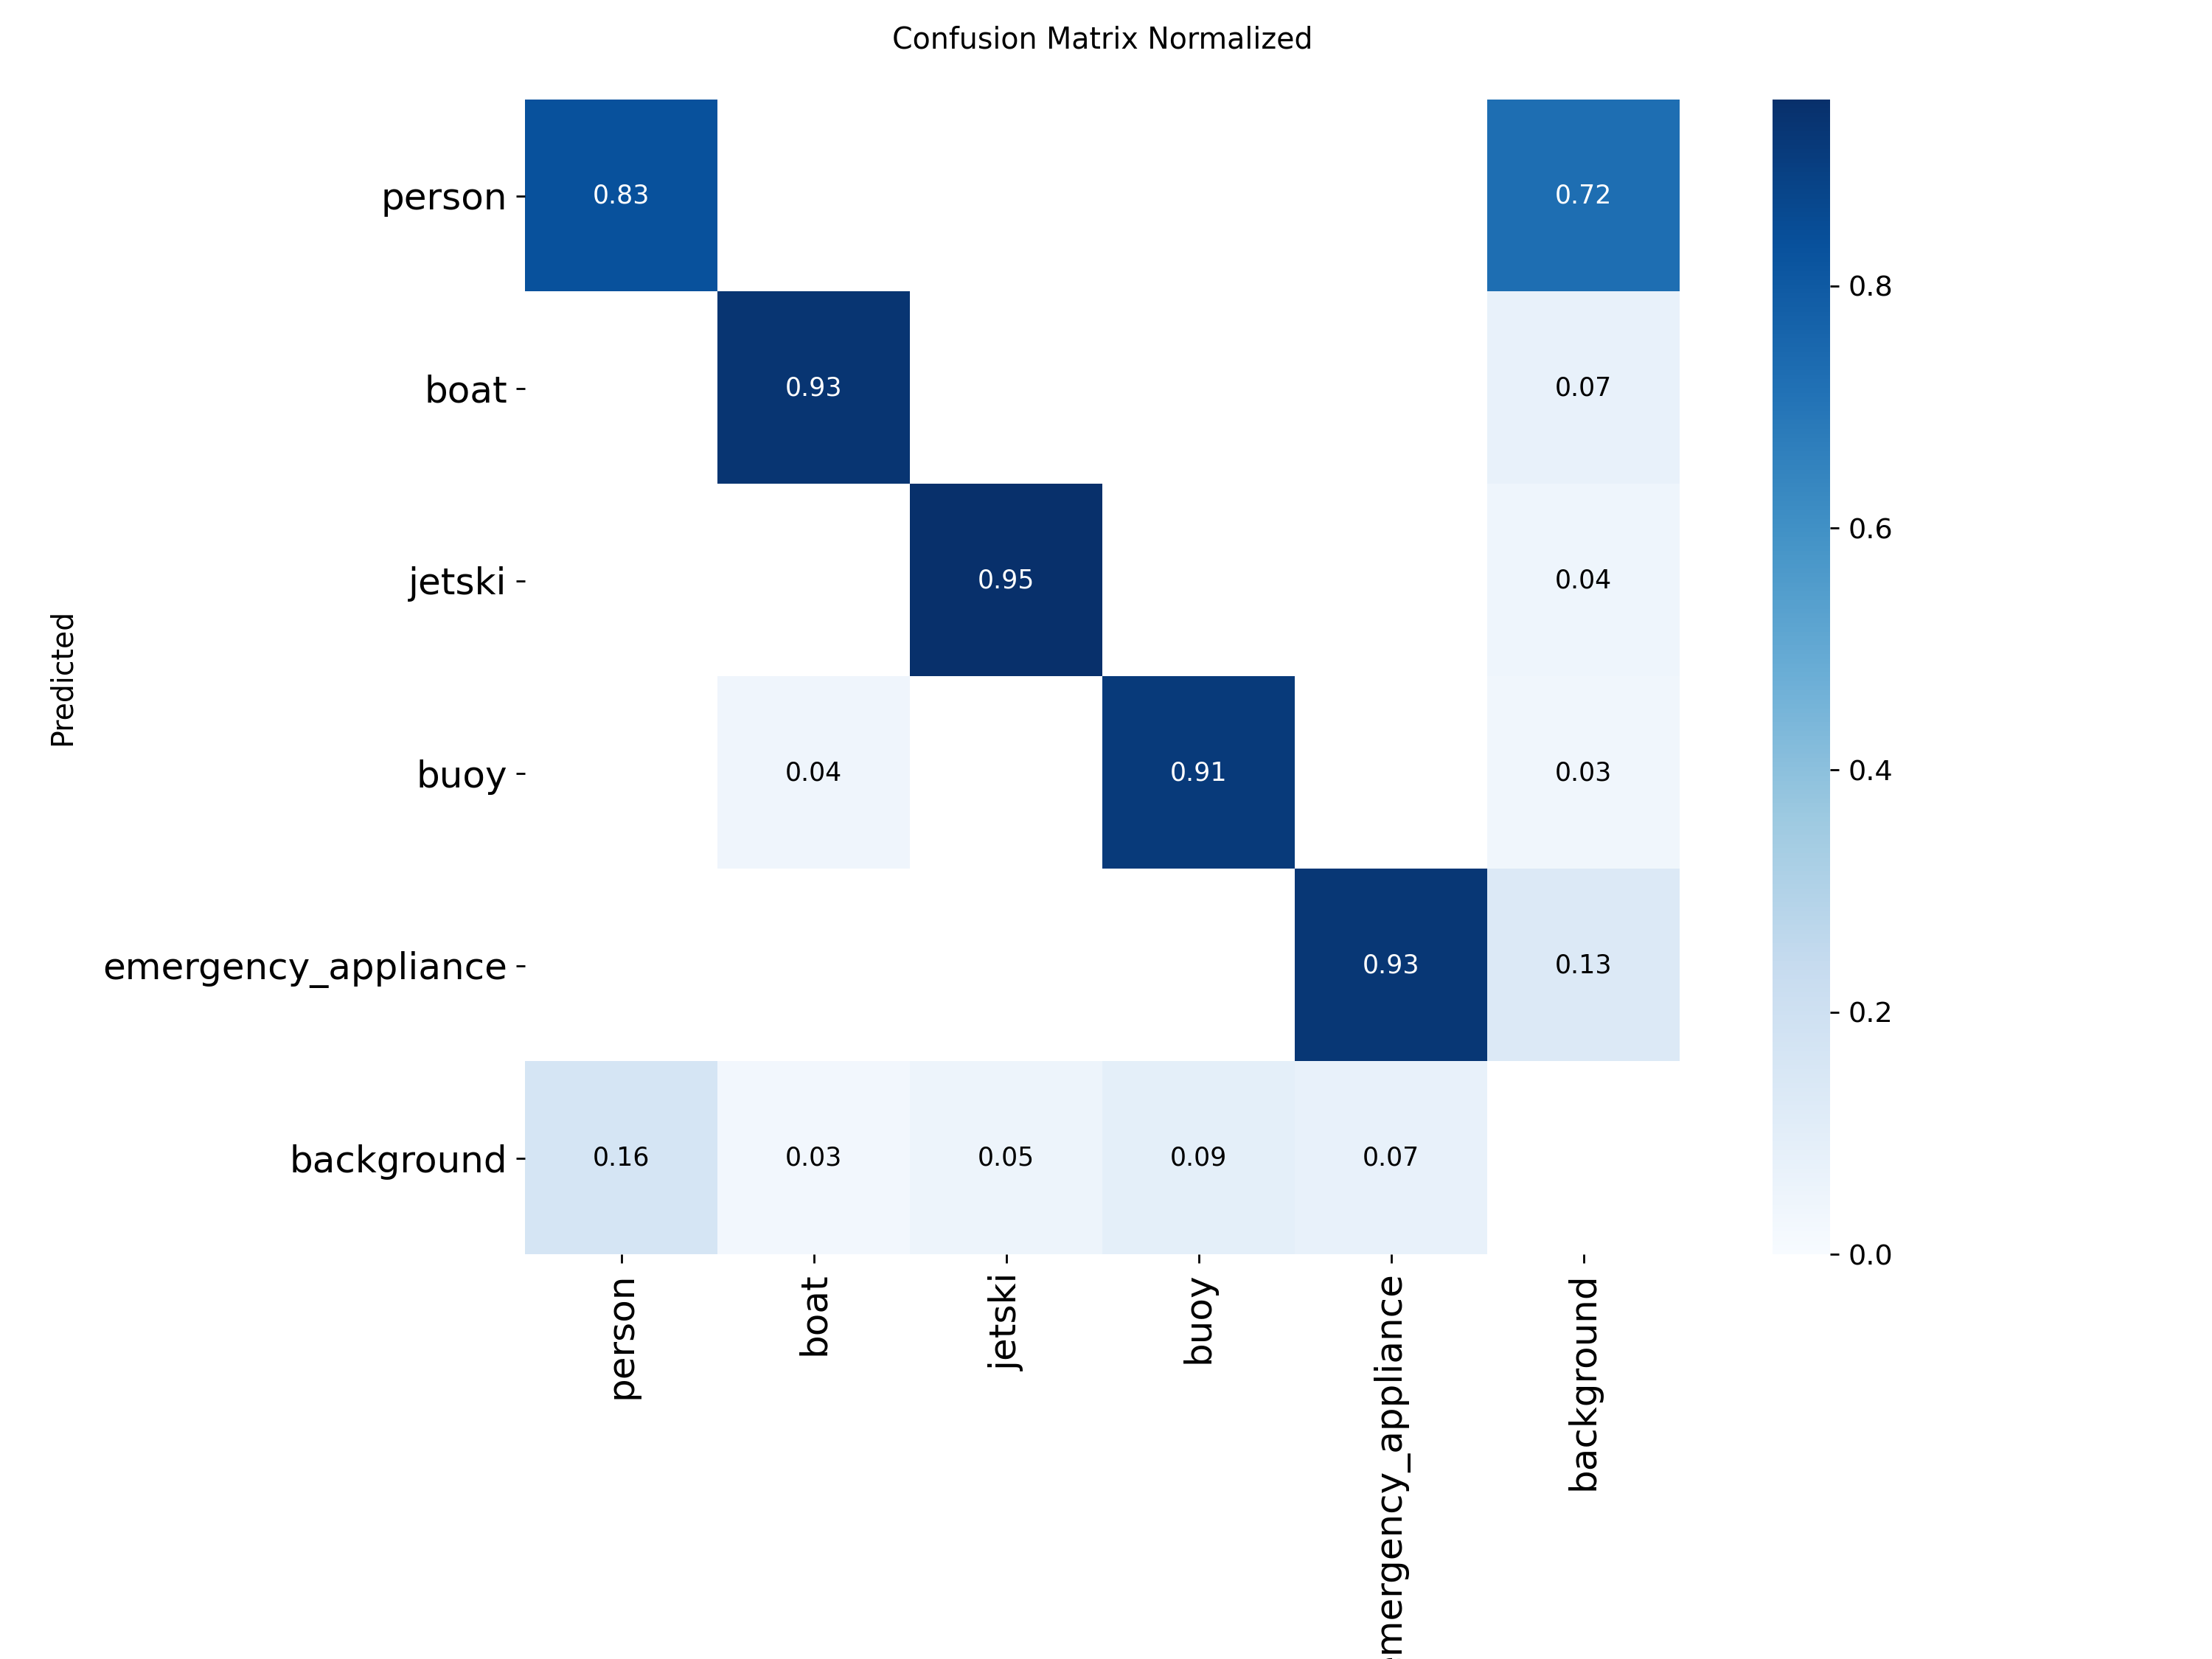

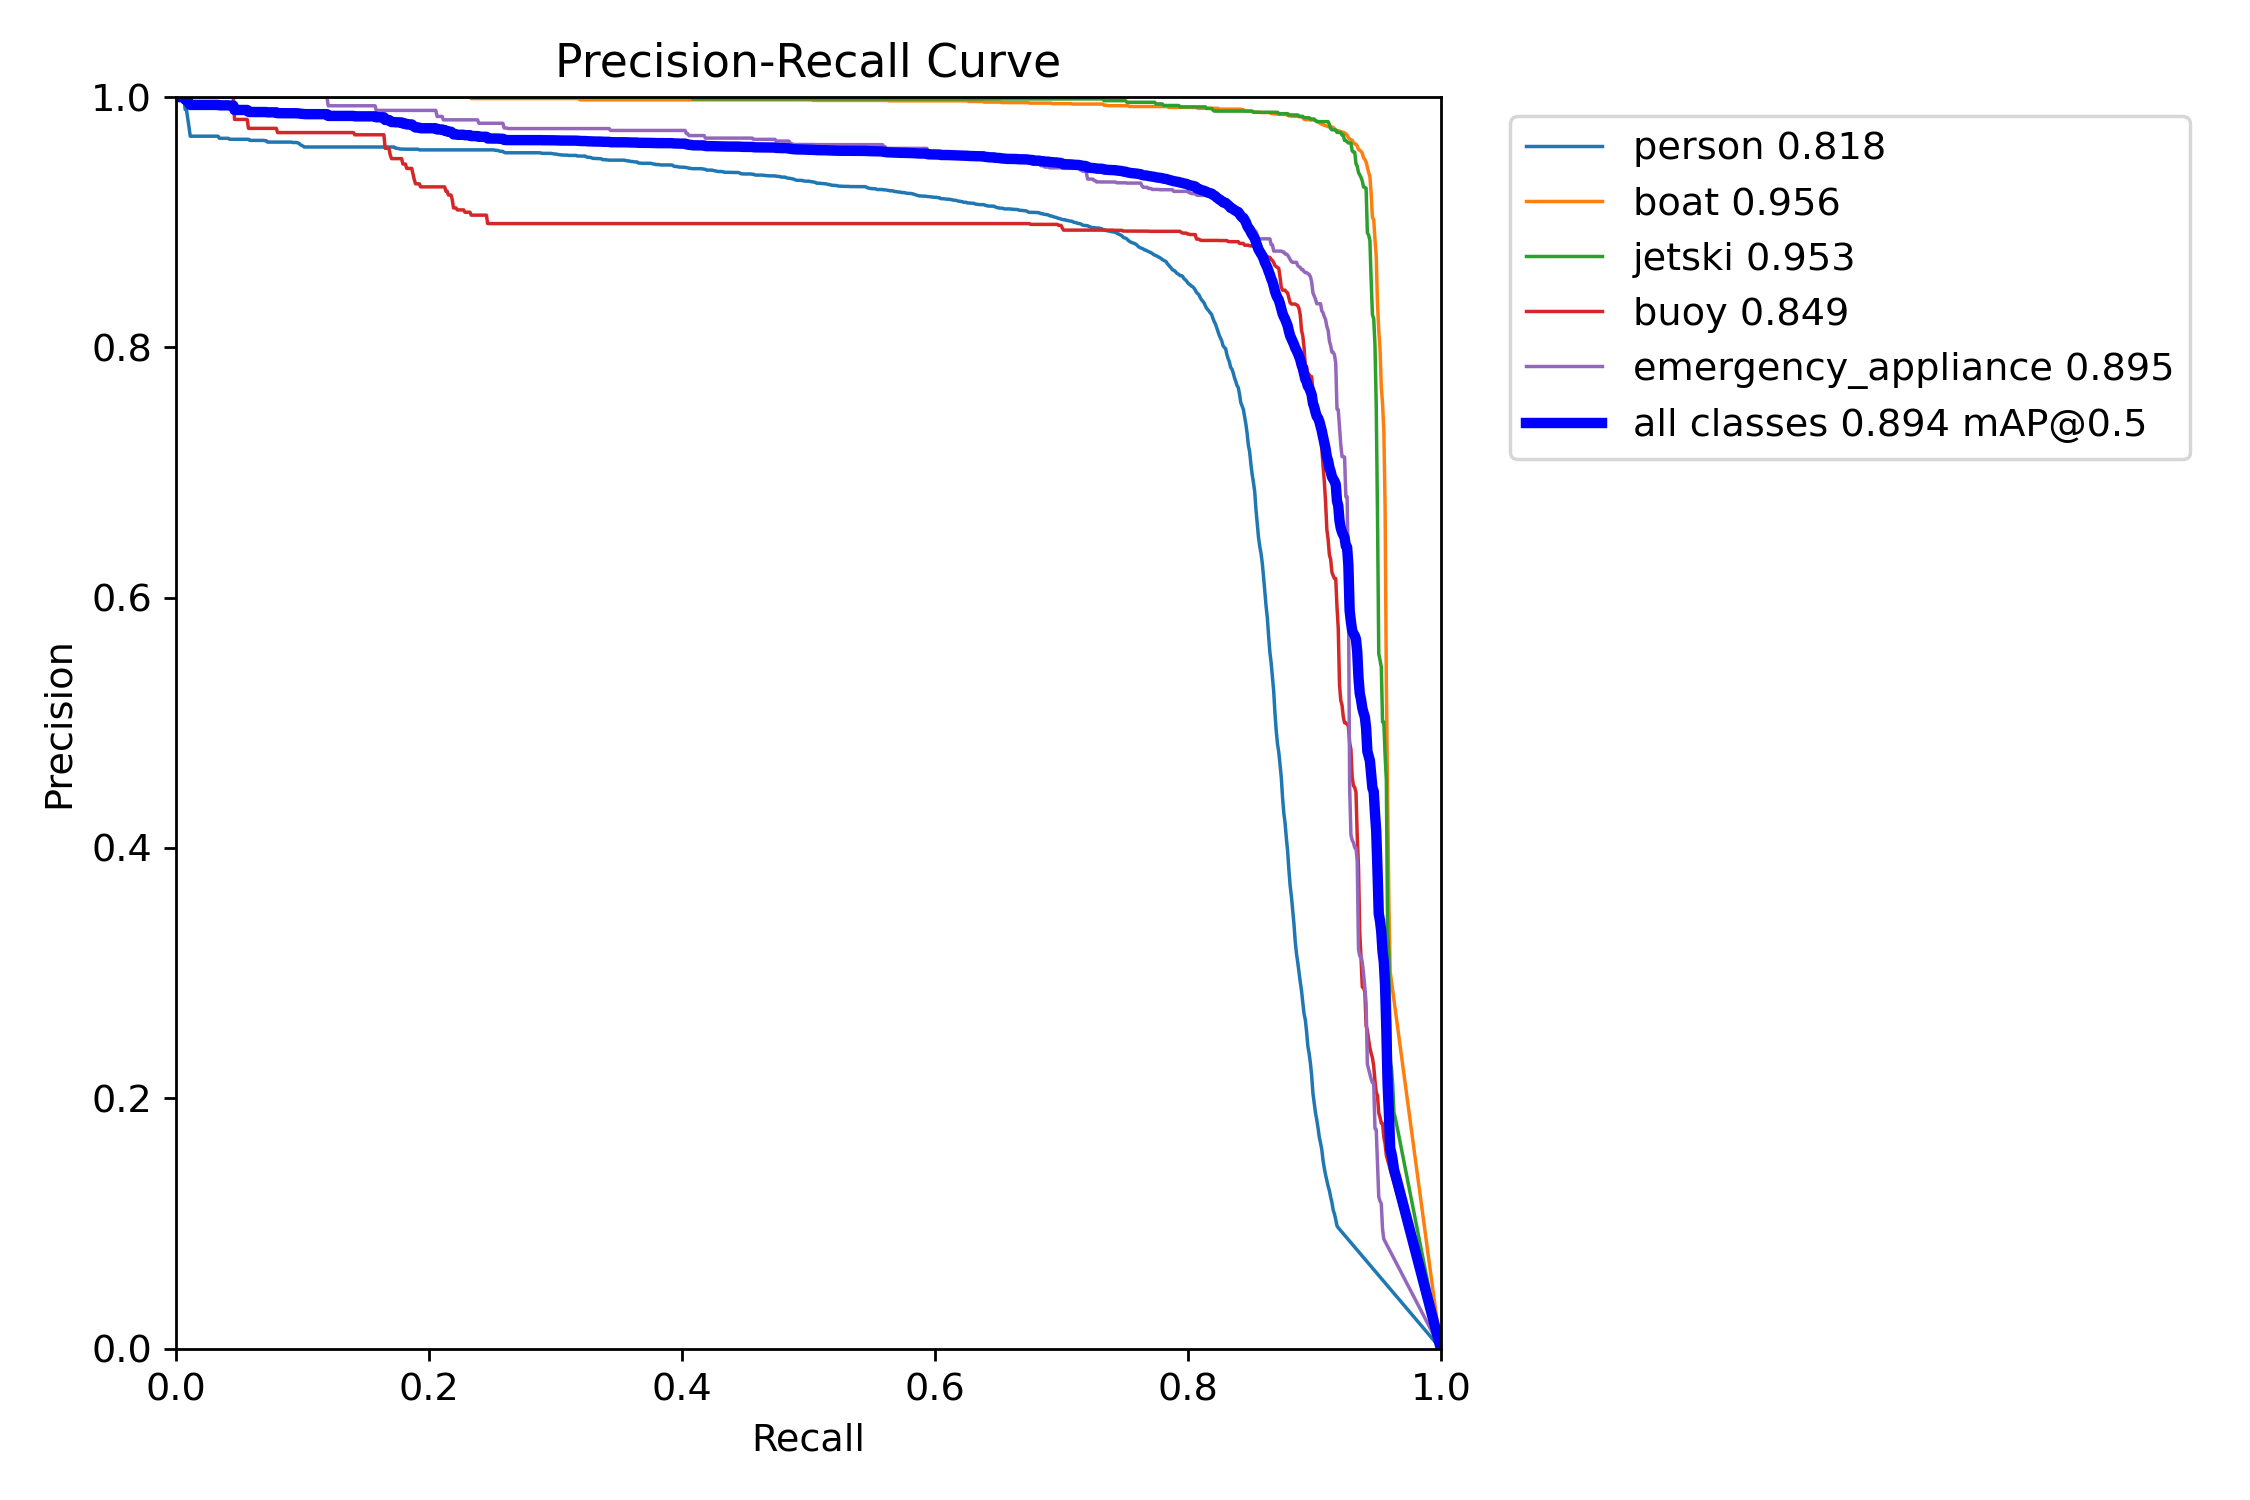

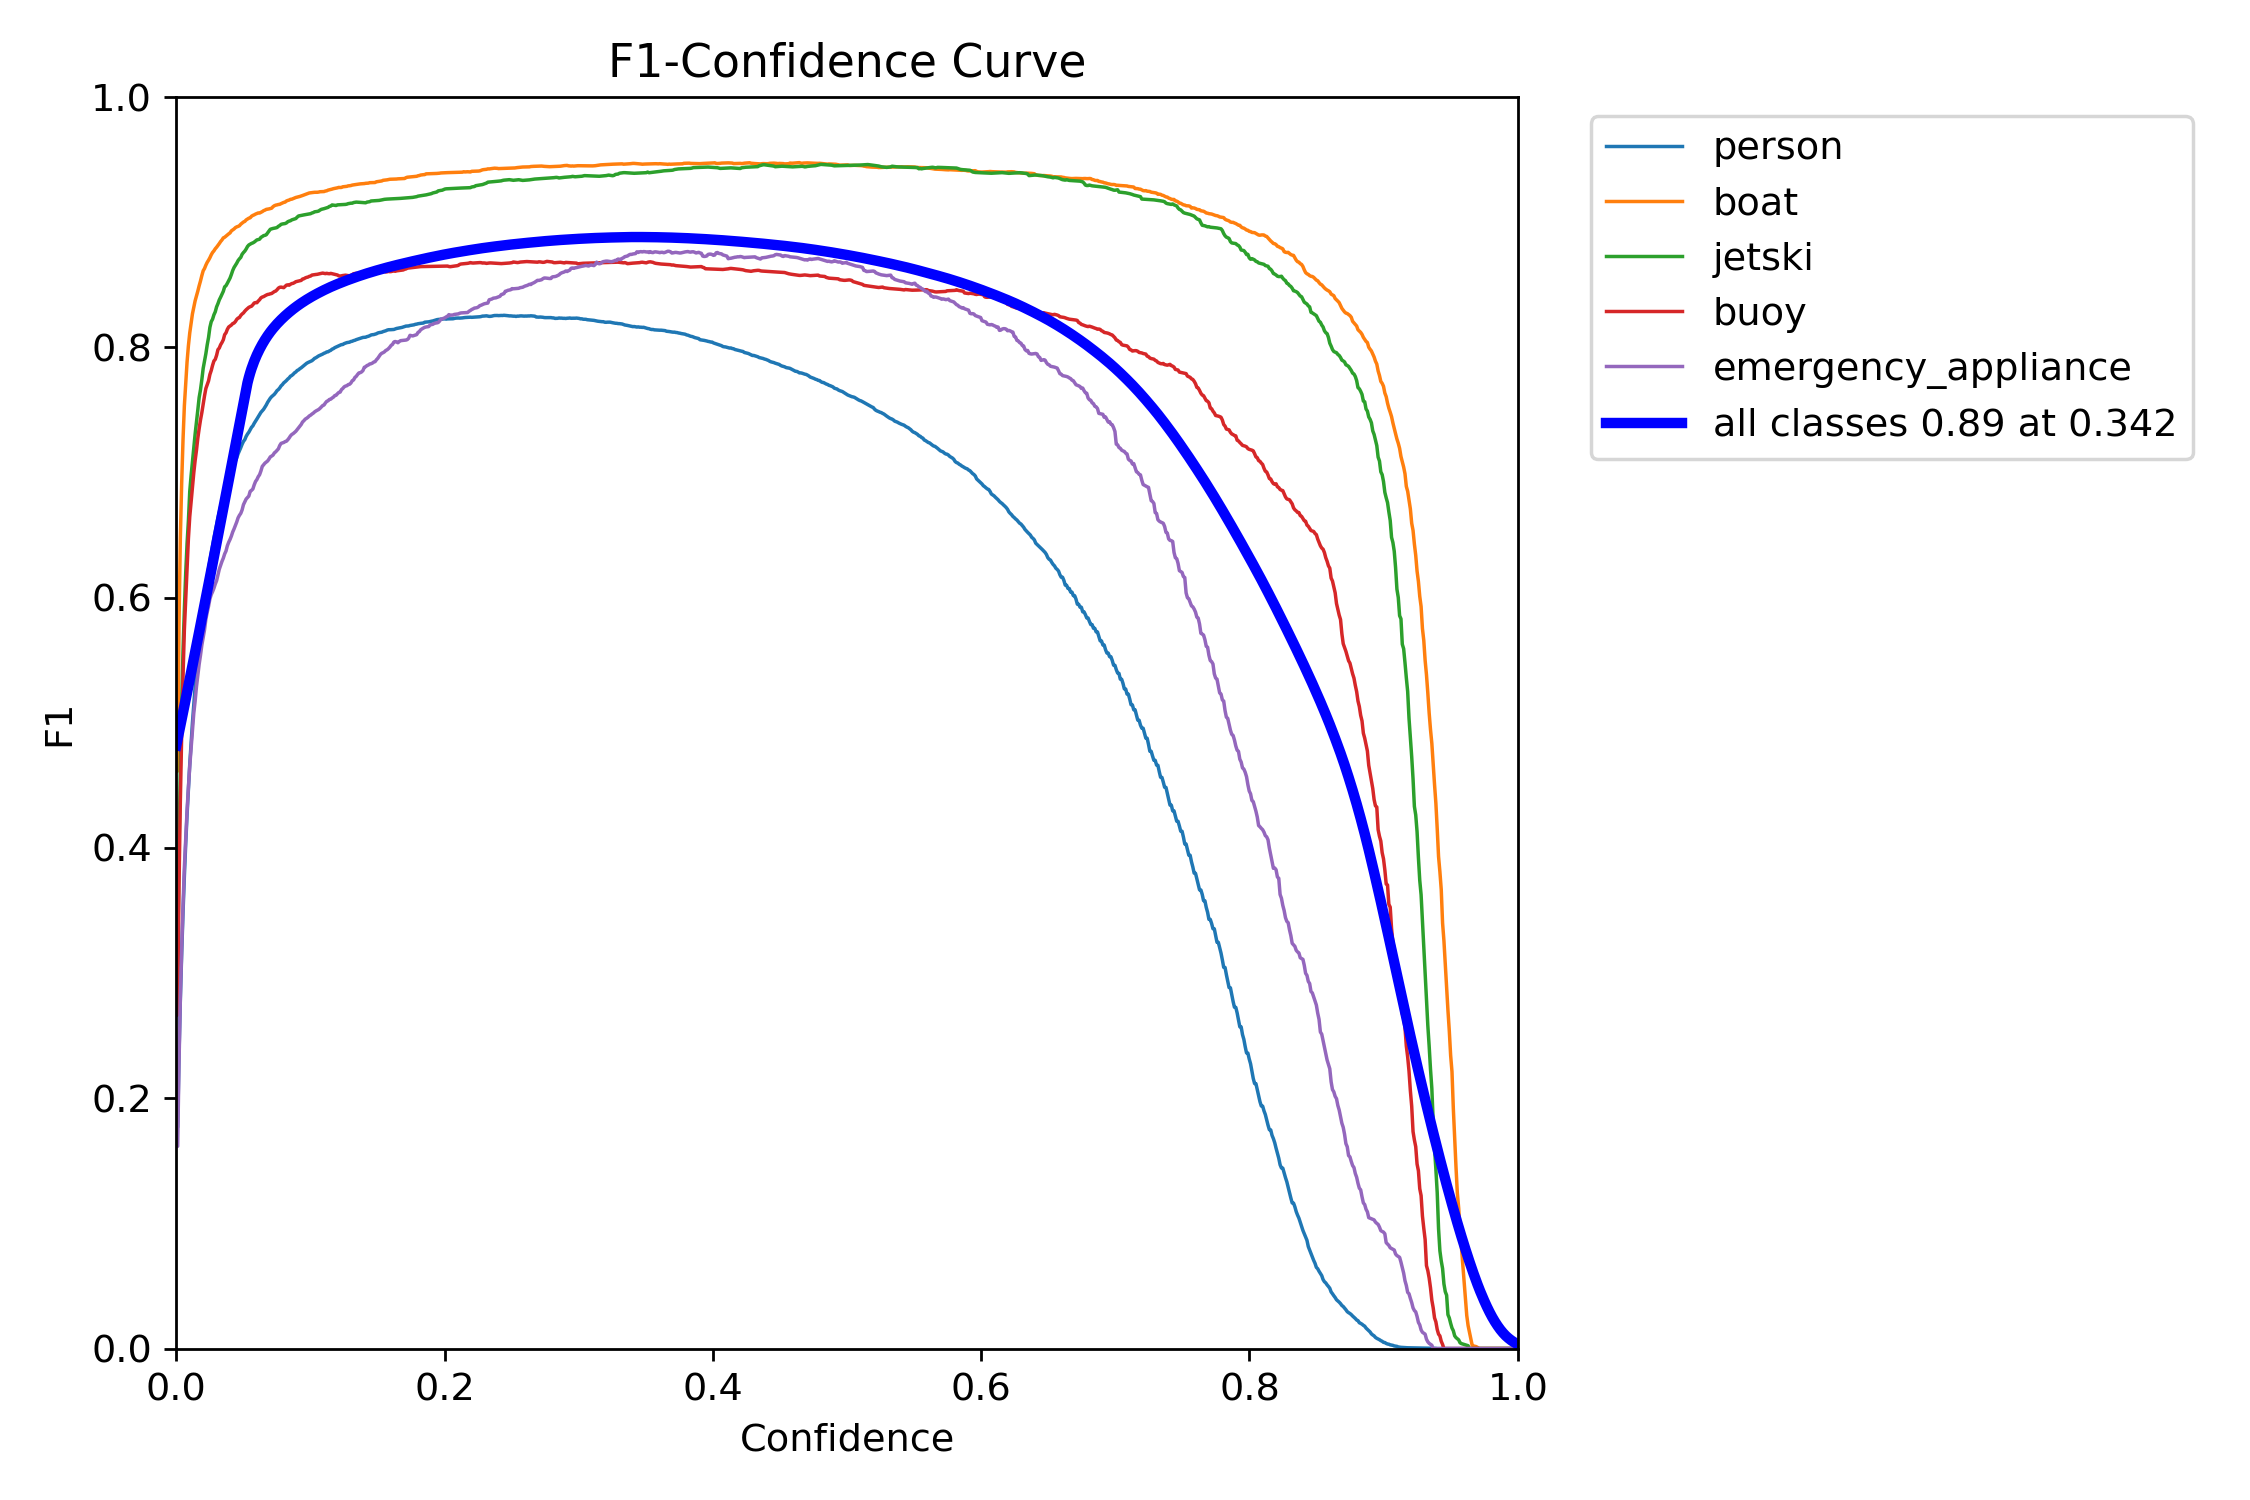

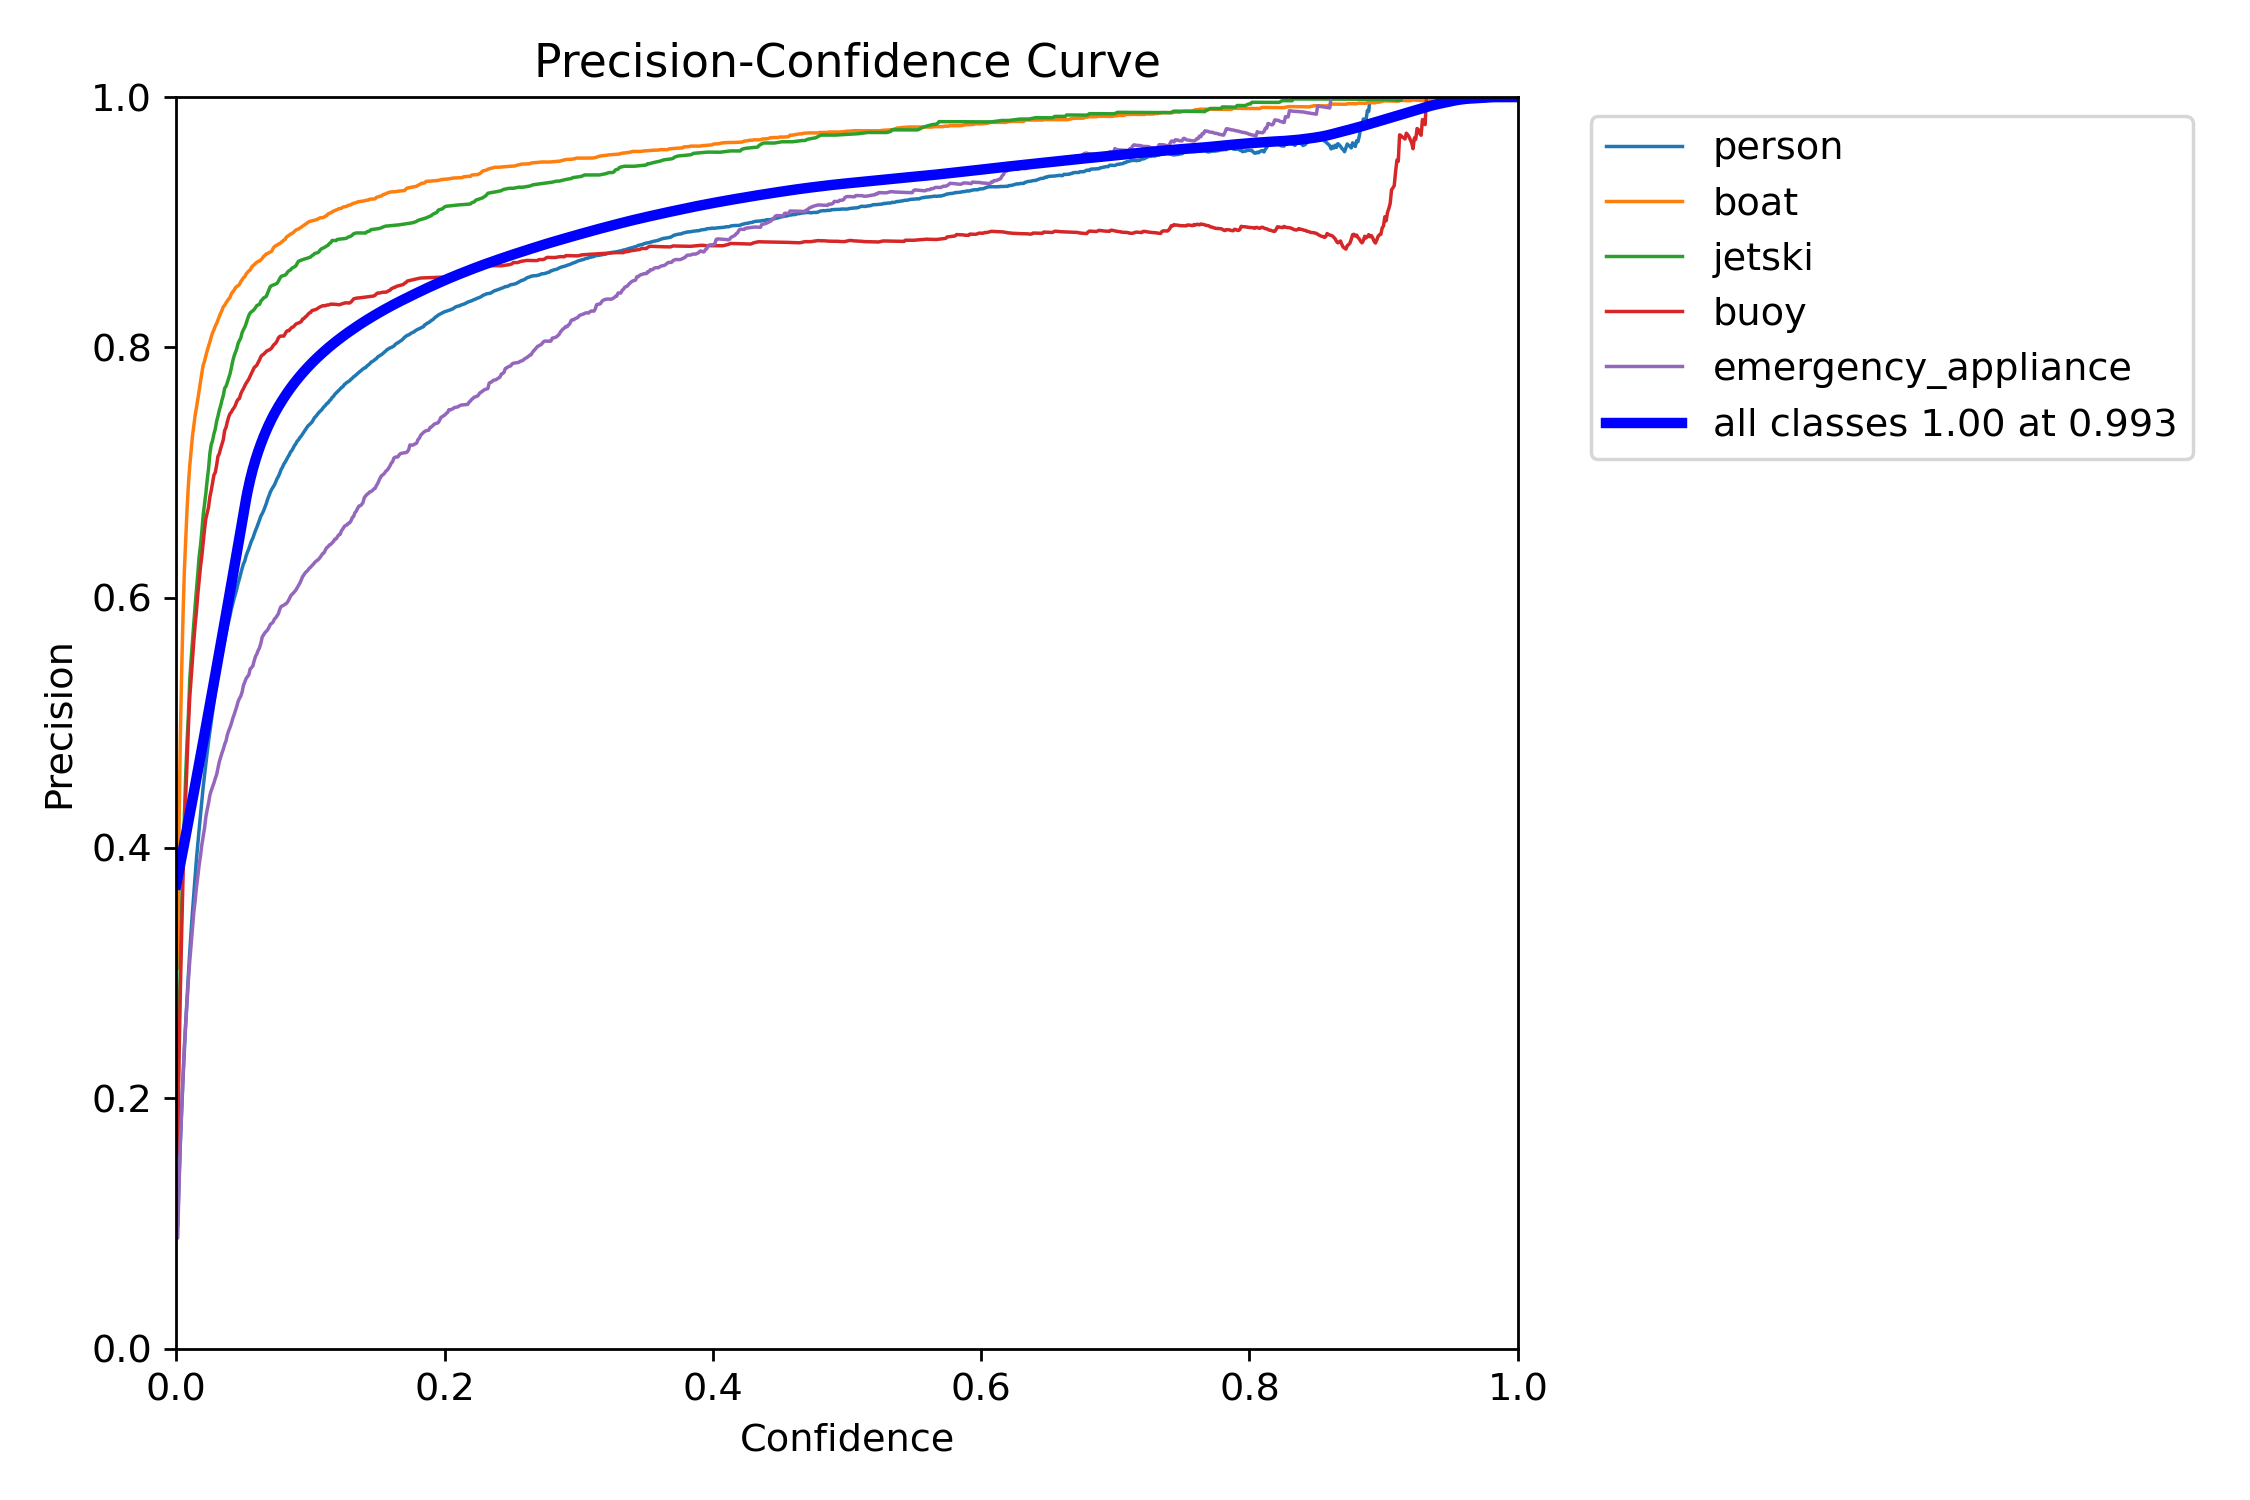

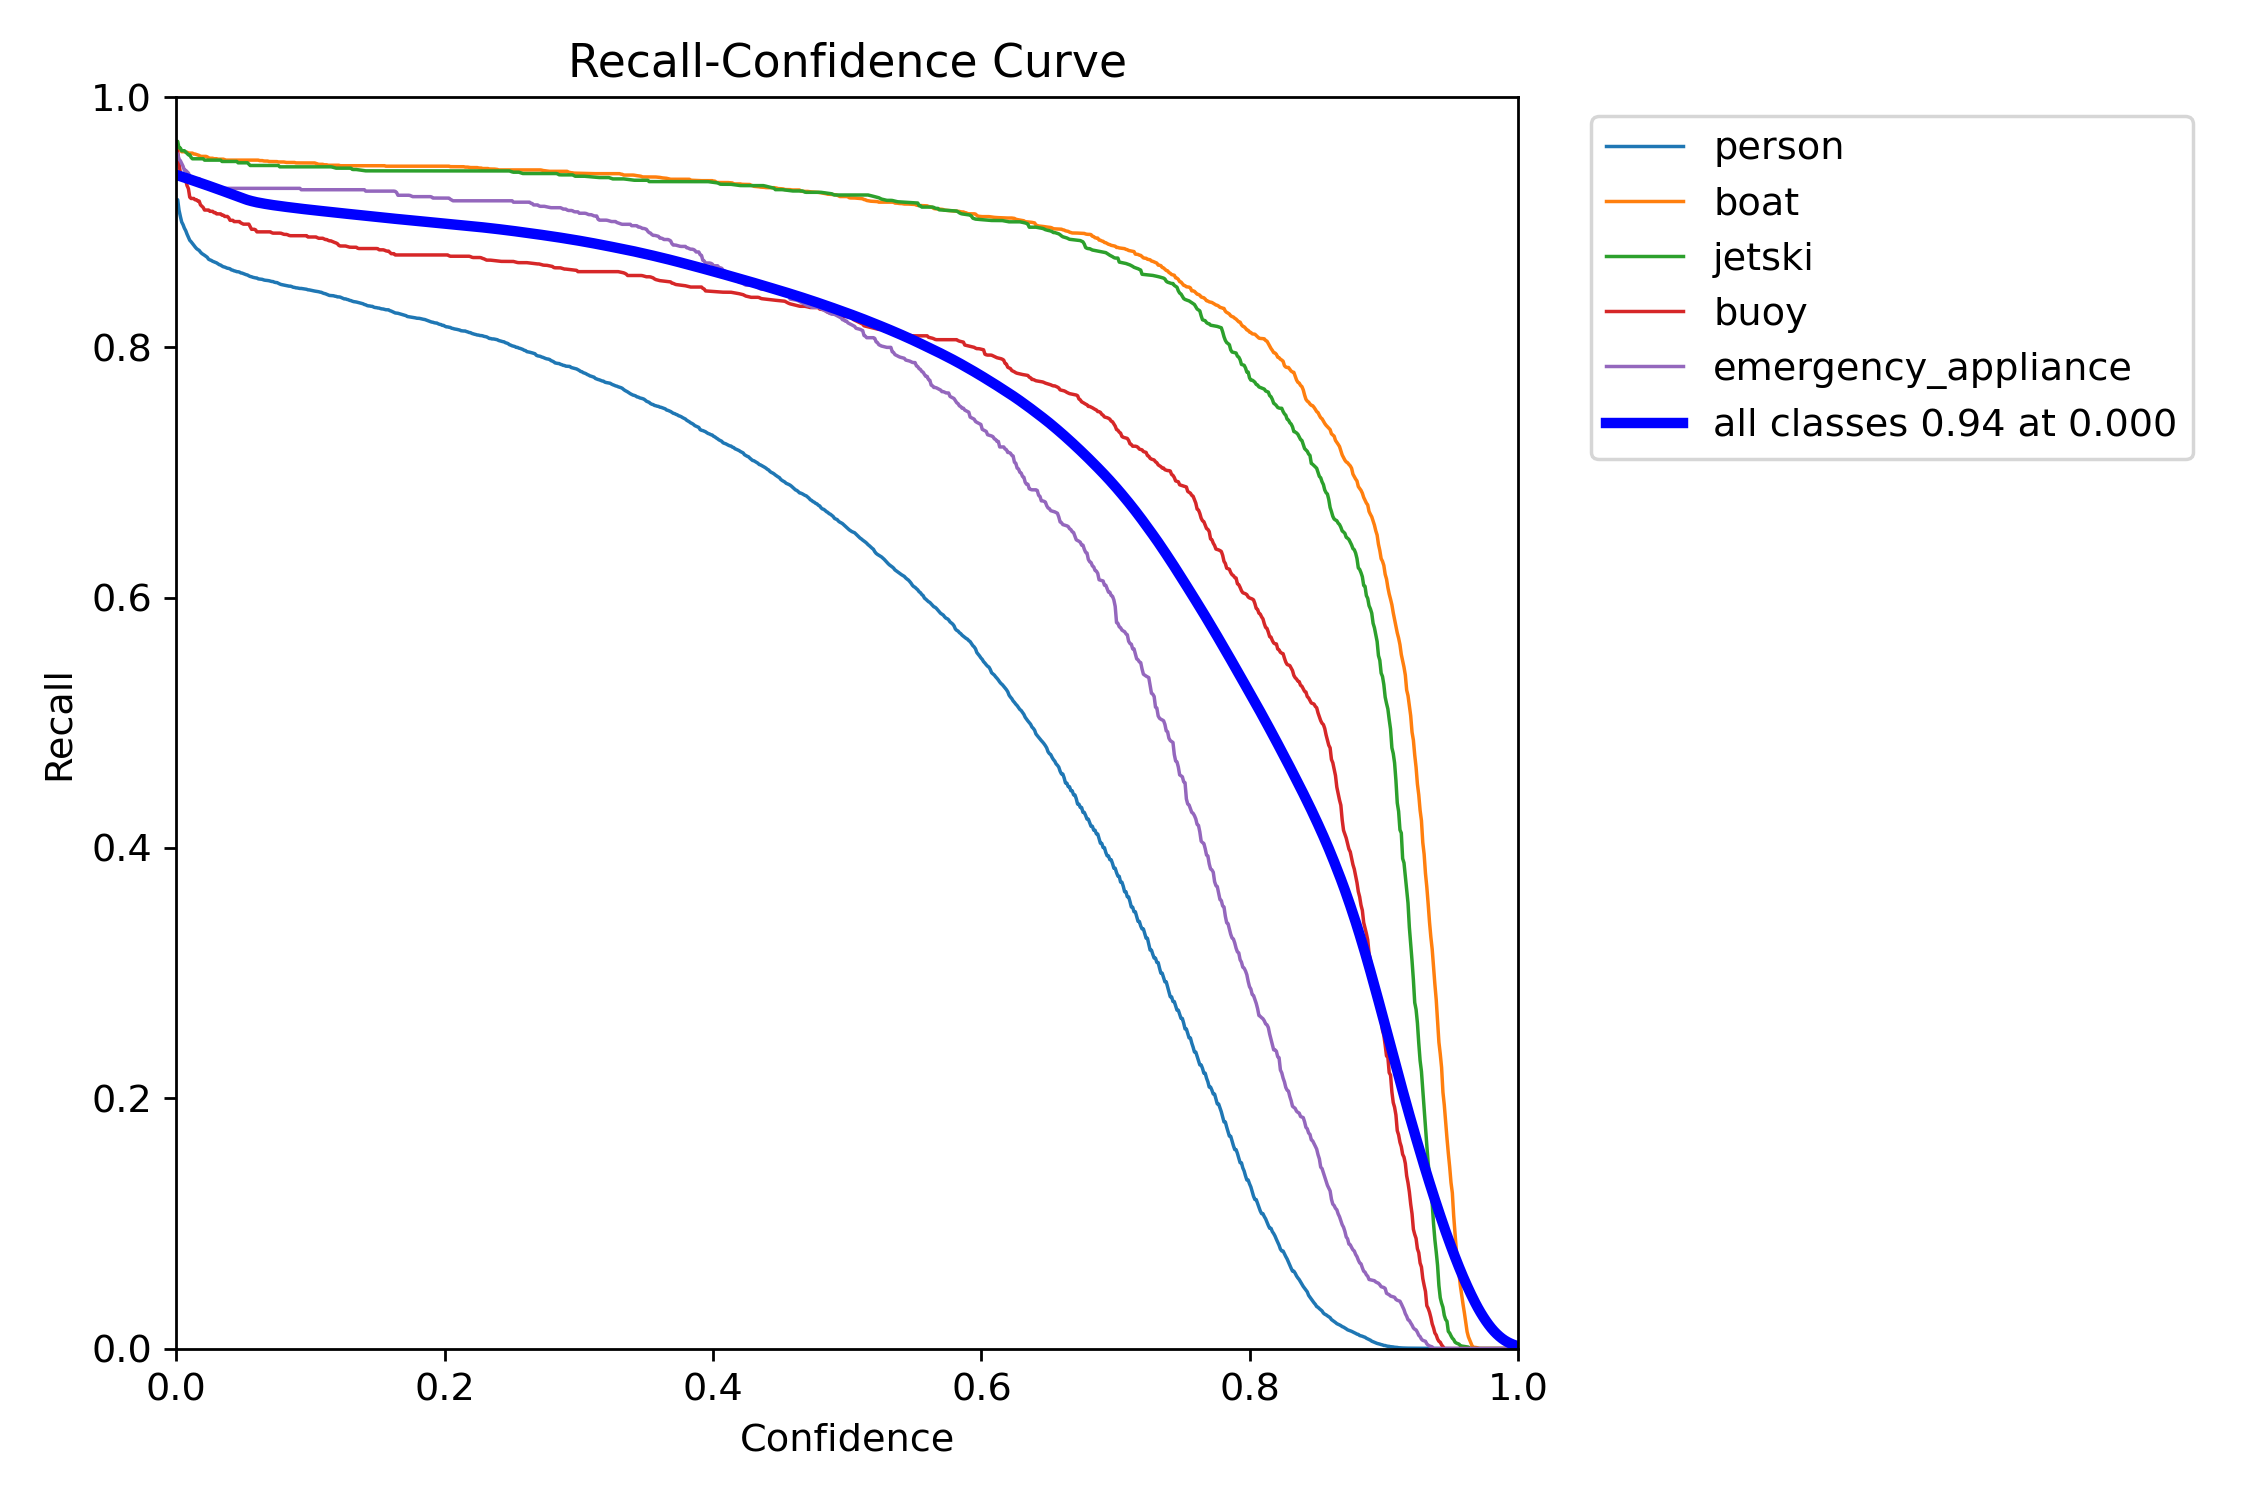

In [5]:
base_path = "/kaggle/working/runs/detect/training_iteration_1/training_iteration_1"
display(Image(f"{base_path}/confusion_matrix_normalized.png"))
display(Image(f"{base_path}/BoxPR_curve.png"))
display(Image(f"{base_path}/BoxF1_curve.png"))
display(Image(f"{base_path}/BoxP_curve.png"))
display(Image(f"{base_path}/BoxR_curve.png"))